## Анализ сегментов и клиентской базы

**Задачи:**

1. Выделить пользователей с >70% индивидуальных тренировок: средний чек, активность, распределение по городам и полу

2. Найти топ-10 самых активных клиентов: распределение по городам и полу

3. Построить динамику клиентской базы: новые, ушедшие и активные клиенты по месяцам

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('../data/merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### 1. Пользователи с >70% индивидуальных тренировок.

Рассчитаем для этого сегмента:
- средний чек
- среднее число тренировок в месяц
- распределение по городам и полу

In [3]:
# Создадим общий датасет, по которому будем считать средние значения
df_total = df\
    .groupby(['id_user', 'city', 'age', 'gender'])\
    .agg({'cnt_group': 'sum', 'cnt_indiv': 'sum', 'sum_group': 'sum', 'sum_indiv' : 'sum',\
        'cnt_total': 'sum', 'sum_total': 'sum', 'mon' : 'count'})\
    .reset_index()\
    .rename(columns = {'mon' : 'cnt_months'})
df_total.head()

,id_user,city,age,gender,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,cnt_months
0,1000,СПб,44.0,female,0,33,0,58600,33,58600,9
1,1001,Москва,35.0,female,106,23,84800,40000,129,124800,11
2,1002,Москва,34.0,male,64,64,52800,113200,128,166000,11
3,1004,Екатеринбург,60.0,male,0,18,0,32000,18,32000,9
4,1005,СПб,35.0,female,0,7,0,12600,7,12600,2


In [4]:
# Добавим колонку - долю индивидуальных тренировок
df_total['indiv_share'] = df_total['cnt_indiv'] / df_total['cnt_total']
df_total.head()

,id_user,city,age,gender,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,cnt_months,indiv_share
0,1000,СПб,44.0,female,0,33,0,58600,33,58600,9,1.000000
1,1001,Москва,35.0,female,106,23,84800,40000,129,124800,11,0.178295
2,1002,Москва,34.0,male,64,64,52800,113200,128,166000,11,0.500000
3,1004,Екатеринбург,60.0,male,0,18,0,32000,18,32000,9,1.000000
4,1005,СПб,35.0,female,0,7,0,12600,7,12600,2,1.000000


In [5]:
# Выделим долю пользователей с 70%+ индивидуальных тренировок
users_indiv_70_plus = df_total[df_total['indiv_share'] >= 0.7].sort_values('indiv_share')

In [6]:
# Посчитаем для них средний чек
users_indiv_70_plus['avg_receipt_month'] = users_indiv_70_plus['sum_total'] / users_indiv_70_plus['cnt_months']

In [7]:
# Посчитаем для них среднее кол-во тренировок в месяц
users_indiv_70_plus['avg_cnt_tr_per_month'] = users_indiv_70_plus['cnt_total'] / users_indiv_70_plus['cnt_months']
users_indiv_70_plus.head()

,id_user,city,age,gender,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,cnt_months,indiv_share,avg_receipt_month,avg_cnt_tr_per_month
276,1334,Казань,41.0,female,11,28,8800,50400,39,59200,4,0.717949,14800.000000,9.750000
457,1549,Москва,50.0,female,3,9,2400,16200,12,18600,3,0.750000,6200.000000,4.000000
0,1000,СПб,44.0,female,0,33,0,58600,33,58600,9,1.000000,6511.111111,3.666667
522,1621,Москва,39.0,male,0,16,0,28800,16,28800,4,1.000000,7200.000000,4.000000
523,1622,Москва,28.0,female,0,36,0,63600,36,63600,8,1.000000,7950.000000,4.500000


In [8]:
# Общее среднее количество тренировок в месяц для пользователей с 70%+ индивидуальных тренировок:
avg_cnt_tr_indiv_70_plus = users_indiv_70_plus['cnt_total'].sum() / users_indiv_70_plus['cnt_months'].sum()
avg_cnt_tr_indiv_70_plus

3.331854480922804

In [9]:
####################################################################################################################

In [10]:
# Разбивка по городам и полу. Общая статистика.
city_gender_stats = users_indiv_70_plus.groupby(['city', 'gender']).agg(
    user_count=('id_user', 'count'),
    avg_receipt_month=('sum_total', 'sum'),
    cnt_months=('cnt_months', 'sum'))

city_gender_stats['avg_receipt_month'] = city_gender_stats['avg_receipt_month'] / city_gender_stats['cnt_months']
#Оставим нужные колонки
city_gender_stats = city_gender_stats.drop('cnt_months', axis=1)
city_gender_stats

user_count  avg_receipt_month
city         gender                               
Екатеринбург female          12        5911.538462
             male            12        5566.101695
Казань       female           8        6545.454545
             male            12        5796.078431
Москва       female         118        5623.829787
             male            59        6756.637168
СПб          female          32        6437.142857
             male            28        4882.242991

In [11]:
# Кто чаще выбирает индивидуальные тренировки?
by_gender = users_indiv_70_plus\
    .groupby('gender')\
    .agg(user_count=('id_user', 'count'), sum_total=('sum_total', 'sum'), cnt_months=('cnt_months', 'sum'))

by_gender['avg_receipt_month'] = by_gender['sum_total'] / by_gender['cnt_months']
by_gender[['user_count', 'avg_receipt_month']]

,user_count,avg_receipt_month
gender,,
female,170,5841.812865
male,111,6034.762980


Вывод: среди пользователей с 70%+ индивидуальных тренировок большинство - женщины (~60%)
Также женщины в этом срезе оставляют больше денег в течение месяца, чем мужчины, исключение - Москва.

In [12]:
# По городам:
by_city = users_indiv_70_plus\
    .groupby('city')\
    .agg(user_count=('id_user', 'count'), sum_total=('sum_total', 'sum'), cnt_months=('cnt_months', 'sum'))

by_city['avg_receipt_month'] = by_city['sum_total'] / by_city['cnt_months']
by_city.loc[:, ['user_count', 'avg_receipt_month']].sort_values('user_count', ascending=False)

,user_count,avg_receipt_month
city,,
Москва,177,5991.666667
СПб,60,5763.562753
Екатеринбург,24,5727.927928
Казань,20,6021.917808


Вывод: В Москве в силу масштаба больше всего клиентов, которые выбирают индивидуальные тренировки.

В сравнении сдругими городами жители Москвы тратят больше средств на тренировки в течение месяца.

В Казани самый высокий средний чек за месяц среди пользователей c 70% индивидуальных тренировок. Однако и самих таких клиентов всего 20: большую цифру делает очень небольшая группа людей.

### 2. Топ-10 самых активных клиентов

- Определим 10 пользователей с наибольшим общим количеством посещений.

- Проанализируем их распределение по городам и полу.

In [13]:
# Топ-10 пользователей с наибольшим общим количеством посещений
df_total.sort_values('cnt_total', ascending = False).iloc[:10]

,id_user,city,age,gender,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,cnt_months,indiv_share
319,1381,Москва,25.0,female,137,22,109600,38000,159,147600,12,0.138365
12,1013,Москва,43.0,male,132,19,105600,34200,151,139800,11,0.125828
551,1657,СПб,27.0,male,91,53,72800,91400,144,164200,10,0.368056
420,1506,Москва,29.0,female,102,36,82400,64000,138,146400,10,0.260870
780,1929,Москва,32.0,male,117,13,93600,23000,130,116600,11,0.100000
1,1001,Москва,35.0,female,106,23,84800,40000,129,124800,11,0.178295
474,1570,Екатеринбург,39.0,male,129,0,103200,0,129,103200,11,0.000000
2,1002,Москва,34.0,male,64,64,52800,113200,128,166000,11,0.500000
485,1582,Екатеринбург,37.0,male,93,34,76000,60200,127,136200,8,0.267717
168,1194,СПб,27.0,female,114,13,91200,23400,127,114600,12,0.102362


In [14]:
top10_visitors = (df_total.sort_values('cnt_total', ascending = False).iloc[:10]['id_user']).to_list()
print(top10_visitors)

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]


In [15]:
df_total[df_total['id_user'].isin(top10_visitors)]\
    .groupby('city')\
    .agg({'id_user':'count'})\
    .reset_index()

,city,id_user
0,Екатеринбург,2
1,Москва,6
2,СПб,2


Больше всего самых активных клиентов в Москве

In [16]:
df_total[df_total['id_user'].isin(top10_visitors)]\
    .groupby('gender')\
    .agg({'id_user':'count'})\
    .reset_index()

,gender,id_user
0,female,4
1,male,6


По полу разницы особой нет. Мужчин немного больше , чем женщин, почти поровну.

In [17]:
pd.pivot_table(df_total[df_total['id_user'].isin(top10_visitors)],\
              index = 'city',\
              columns = 'gender',\
              values = 'id_user',\
              aggfunc = 'count',\
              fill_value = 0).astype(int)

gender,female,male
city,,
Екатеринбург,0,2
Москва,3,3
СПб,1,1


### 3. Динамика клиентской базы

Рассчитаем для каждого месяца:

- новых клиентов (первый месяц активности)
- ушедших клиентов (последний месяц активности)
- активных клиентов

Построим линейный график.

In [18]:
# 1. Создаем датафрейм с новыми клиентами по месяцам
new_clients = df.groupby('min_mon')['id_user'].nunique().reset_index().rename(columns = {'id_user' : 'new_users'})
new_clients

,min_mon,new_users
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57
5,2023-06,51
6,2023-07,48
7,2023-08,35
8,2023-09,28
9,2023-10,27


In [19]:
# 2. Создаем датафрейм с ушедшими клиентами по месяцам
gone_clients = df.groupby('max_mon')['id_user'].nunique().reset_index().rename(columns = {'id_user' : 'gone_users'})
gone_clients

,max_mon,gone_users
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21
5,2023-06,13
6,2023-07,33
7,2023-08,33
8,2023-09,55
9,2023-10,101


In [20]:
# 3. Активные клиенты по месяцам
active_clients = df.groupby('mon')['id_user'].nunique().reset_index().rename(columns = {'id_user' : 'active_users'})
active_clients

,mon,active_users
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360
5,2023-06,383
6,2023-07,412
7,2023-08,423
8,2023-09,429
9,2023-10,441


In [21]:
# 4. Объединяем все три датафрейма
result = active_clients\
          .merge(new_clients, left_on='mon', right_on='min_mon', how='left')\
          .merge(gone_clients, left_on='mon', right_on='max_mon', how='left')\
          .fillna(0)\
          .sort_values('mon')\
          .loc[:, ['mon', 'active_users', 'new_users', 'gone_users']]
        
result

,mon,active_users,new_users,gone_users
0,2023-01,337,337,15
1,2023-02,350,88,22
2,2023-03,355,83,37
3,2023-04,345,62,21
4,2023-05,360,57,21
5,2023-06,383,51,13
6,2023-07,412,48,33
7,2023-08,423,35,33
8,2023-09,429,28,55
9,2023-10,441,27,101


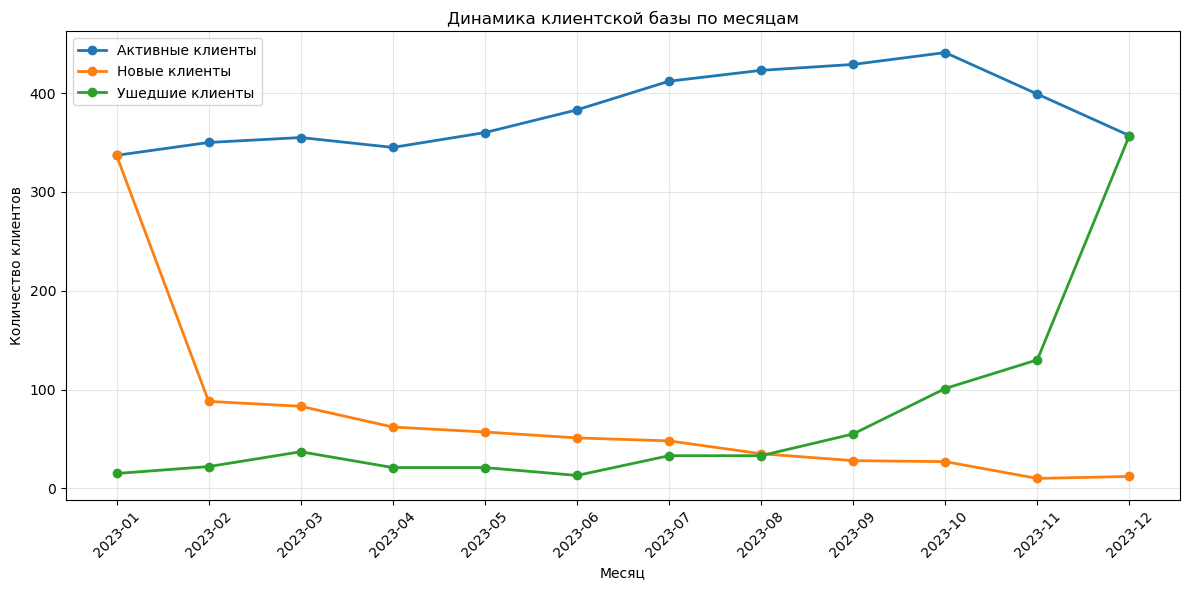

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(result['mon'], result['active_users'], marker='o', label='Активные клиенты', linewidth=2)
plt.plot(result['mon'], result['new_users'], marker='o', label='Новые клиенты', linewidth=2)
plt.plot(result['mon'], result['gone_users'], marker='o', label='Ушедшие клиенты', linewidth=2)

plt.xlabel('Месяц')
plt.ylabel('Количество клиентов')
plt.title('Динамика клиентской базы по месяцам')
plt.legend()
plt.xticks(rotation = 45)
plt.grid(alpha = .3)
plt.tight_layout()
plt.show()

На протяжении всего периода наблюдений видно, что кол-во новых клиeнтов идёт на спад, а уходящих, наоборот, растёт. 
При этом большую часть года поддерживается положительная динамика роста клиентской базы и только в конце года, начиная с октября, наблюдается резкий отток.